# 121 · Chess Siamese — TESTS (modelo 120)

Notebook de verificación **post-entrenamiento** usando el mismo protocolo del `111`,
pero cargando el modelo obtenido en `120`.


## Objetivos de esta batería

- Repetir la batería del `111` para poder contrastar manualmente ambos modelos.
- Evaluar jugadores vistos (hold-out): Top-1/Top-3/Top-5, confusión, recall por jugador.
- Revisar separabilidad del embedding por distancias.
- Probar jugadores no vistos (open-set) desde `.zst` y medir similitud por ELO.
- Entregar resúmenes descriptivos en porcentaje.


In [1]:
import io
import math
import random
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import chess
import chess.pgn
import chess.svg
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import zstandard as zstd
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    top_k_accuracy_score,
)
from sklearn.neighbors import KNeighborsClassifier

SEED = 314159
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use("seaborn-v0_8")
sns.set_context("talk")

print(f"TensorFlow {tf.__version__}")


2026-05-20 13:36:49.622116: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-20 13:36:49.675526: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-20 13:36:49.691485: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-20 13:36:49.759046: I tensorflow/core/platform/cpu_feature_guard.cc:211] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow 2.17.0


In [2]:
TRAINED_PLAYERS = []


@dataclass
class EvalConfig:
    event_name: str = "compressed_130"
    sequence_len: int = 15
    fullmove_start: int = 15
    fullmove_end: int = 60
    image_size: Tuple[int, int] = (192, 192)
    embedding_dim: int = 256
    validation_fraction: float = 0.2
    min_samples_per_player: int = 12
    infer_batch_size: int = 4

    unknown_players_to_test: int = 20
    unknown_games_per_player: int = 20
    unknown_candidate_pool: int = 200
    unknown_min_elo: int = 800
    unknown_max_elo: int = 2600
    ood_quantile: float = 0.95


CONFIG = EvalConfig()
PLY_LABELS = [f"ply{i:02d}" for i in range(1, CONFIG.sequence_len + 1)]


def detect_repo_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "labs").exists():
            return candidate
    raise RuntimeError("No se encontró raíz del repo (carpeta labs/).")


def first_existing(candidates: List[Path], description: str) -> Path:
    for candidate in candidates:
        if candidate.exists():
            return candidate
    joined = "\n".join(str(c) for c in candidates)
    raise RuntimeError(f"No se encontró {description}. Candidatos:\n{joined}")


def discover_event_players(*dir_pairs: Tuple[Path, Path]) -> List[str]:
    player_sets = []
    for board_dir, heat_dir in dir_pairs:
        if not board_dir.exists() or not heat_dir.exists():
            continue
        players = {
            d.name
            for d in board_dir.iterdir()
            if d.is_dir() and (heat_dir / d.name).is_dir()
        }
        if players:
            player_sets.append(players)

    if not player_sets:
        raise RuntimeError("No se pudieron inferir jugadores entrenados desde el evento.")

    common_players = set.intersection(*player_sets) if len(player_sets) > 1 else player_sets[0]
    out = sorted(common_players)
    if not out:
        raise RuntimeError("La intersección de jugadores TRAIN/HOLDOUT está vacía.")
    return out


REPO_ROOT = detect_repo_root()

EVENT_DIR = first_existing(
    [
        REPO_ROOT / "labs" / "notebooks" / "output" / "events" / CONFIG.event_name,
        Path("/workspace/code/labs/notebooks/output/events") / CONFIG.event_name,
        Path(r"D:\CODE\jupyter\labs\notebooks\output\events") / CONFIG.event_name,
    ],
    "directorio del evento 130",
)

TRAIN_BOARD_DIR = EVENT_DIR / "board_images"
TRAIN_HEAT_DIR = EVENT_DIR / "heatmap_images"
HOLDOUT_BOARD_DIR = EVENT_DIR / "holdout_board_images"
HOLDOUT_HEAT_DIR = EVENT_DIR / "holdout_heatmap_images"
PGN_TESTS_DIR = EVENT_DIR / "pgn_tests"

TRAINING_STATE_DIR = EVENT_DIR / "training_state"
CHECKPOINTS_DIR = TRAINING_STATE_DIR / "checkpoints"
BEST_WEIGHTS_PATH = CHECKPOINTS_DIR / "metric_trainer_best.weights.h5"
LAST_WEIGHTS_PATH = CHECKPOINTS_DIR / "metric_trainer_last.weights.h5"
HISTORY_CSV_PATH = TRAINING_STATE_DIR / "history.csv"

ZST_PLAYERS_DIR = first_existing(
    [
        Path("/pgn_data/players"),
        Path(r"D:\pgn_output\players"),
        Path("/workspace/pgn_output/players"),
    ],
    "directorio de jugadores .zst",
)

assert TRAIN_BOARD_DIR.exists(), f"No existe {TRAIN_BOARD_DIR}"
assert HOLDOUT_BOARD_DIR.exists(), f"No existe {HOLDOUT_BOARD_DIR}"

TRAINED_PLAYERS = discover_event_players(
    (TRAIN_BOARD_DIR, TRAIN_HEAT_DIR),
    (HOLDOUT_BOARD_DIR, HOLDOUT_HEAT_DIR),
)

print(f"Repo: {REPO_ROOT}")
print(f"Evento: {EVENT_DIR}")
print(f"ZST dir: {ZST_PLAYERS_DIR}")
print(f"Jugadores entrenados inferidos ({len(TRAINED_PLAYERS)}): {TRAINED_PLAYERS}")


Repo: /workspace/code
Evento: /workspace/code/labs/notebooks/output/events/compressed_130
ZST dir: /pgn_data/players
Jugadores entrenados inferidos (200): ['AdamIsGonnaLose709', 'Addictive187', 'Albatroaz4', 'Alex_marusenko', 'Arielagronomo', 'BIRINA1957', 'BJK1903Q7', 'Barombek77', 'Bazsalikom', 'Belitim', 'Camachogg', 'Ceedevita', 'Cesarbal123', 'ChessVik82', 'Chingiz02', 'Colmar56', 'Compositor58', 'Corsair0', 'Dakkon2007', 'Daniel_Chess_77', 'David-67500', 'DiegoSotto', 'Dis_Ko', 'Dr_Mabuse24', 'EdwardMartens', 'Emrahcetin', 'FX-DANGER', 'Falkenburger', 'Ffferz333', 'Finis777', 'FixAFKLogic', 'GErmaNnadIY_333', 'Getforked2000', 'GoSpikGo', 'Grosfater', 'Himdgr8', 'I2nChess21', 'Ilpanormita', 'Janiszmn', 'Juliano_42', 'KangwaB', 'Karl_Plus', 'Kasalla1', 'Kembang22', 'Komarjolea', 'LFQ', 'Lohne', 'Loyagavictor02', 'MRA95', 'MXMU', 'M_gusak', 'Mailoo', 'Manukya0303', 'Mao308', 'MarcoMazza', 'MarkusMake', 'Mauricio060215', 'Miguel1969', 'Mirian-777', 'Mr_Huxley', 'NourYehia', 'Nunhez',

## 1) Carga de checkpoint del modelo (sin re-entrenar)


In [3]:
def build_embedding_model(
    seq_len: int, image_size: Tuple[int, int], embedding_dim: int
) -> tf.keras.Model:
    h, w = image_size

    board_input = tf.keras.layers.Input(
        shape=(seq_len, h, w, 3), name="board_sequence"
    )
    heat_input = tf.keras.layers.Input(
        shape=(seq_len, h, w, 1), name="heat_sequence"
    )

    base_cnn = tf.keras.applications.ResNet50(
        include_top=False,
        weights=None,  # evita descargas; el checkpoint local repone todos los pesos
        pooling="avg",
        input_shape=(h, w, 3),
    )
    base_cnn.trainable = False

    board_pre = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Lambda(
            lambda x: tf.keras.applications.resnet50.preprocess_input(x * 255.0)
        ),
        name="board_preprocess",
    )(board_input)
    board_features = tf.keras.layers.TimeDistributed(
        base_cnn, name="board_backbone"
    )(board_pre)
    board_features = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(512, activation="gelu"), name="board_dense"
    )(board_features)

    heat_encoder = tf.keras.Sequential(
        [
            tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
            tf.keras.layers.MaxPooling2D(2),
            tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
            tf.keras.layers.MaxPooling2D(2),
            tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
            tf.keras.layers.GlobalAveragePooling2D(),
            tf.keras.layers.Dense(256, activation="gelu"),
        ],
        name="heat_encoder",
    )
    heat_features = tf.keras.layers.TimeDistributed(
        heat_encoder, name="heat_backbone"
    )(heat_input)

    fused = tf.keras.layers.Concatenate(name="fuse_modalities")(
        [board_features, heat_features]
    )
    fused = tf.keras.layers.LayerNormalization(name="fuse_norm")(fused)
    fused = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(512, activation="gelu"), name="fuse_dense"
    )(fused)

    temporal = tf.keras.layers.Bidirectional(
        tf.keras.layers.GRU(
            256,
            return_sequences=True,
            dropout=0.20,
            reset_after=False,
        ),
        name="temporal_gru",
    )(fused)
    pooled = tf.keras.layers.GlobalAveragePooling1D(name="temporal_pool")(temporal)

    x = tf.keras.layers.Dense(512, activation="gelu")(pooled)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(embedding_dim, activation=None, dtype="float32")(x)
    embedding = tf.keras.layers.Lambda(
        lambda t: tf.math.l2_normalize(t, axis=1), name="embedding_l2"
    )(x)

    return tf.keras.Model(
        inputs=[board_input, heat_input],
        outputs=embedding,
        name="stylometry_embedding_104",
    )


class MetricTrainer(tf.keras.Model):
    def __init__(
        self,
        embedding_model: tf.keras.Model,
        num_classes: int,
        margin: float = 0.06,
        ce_weight: float = 0.20,
    ):
        super().__init__()
        self.embedding_model = embedding_model
        self.classifier = tf.keras.layers.Dense(
            num_classes,
            use_bias=False,
            dtype="float32",
            name="classifier",
        )
        self.margin = float(margin)
        self.ce_weight = float(ce_weight)

    def call(self, inputs, training=False):
        emb = self.embedding_model(inputs, training=training)
        logits = self.classifier(emb)
        return emb, logits


def pick_checkpoint_path() -> Path:
    candidates = [
        BEST_WEIGHTS_PATH,
        LAST_WEIGHTS_PATH,
        *sorted(CHECKPOINTS_DIR.glob("*.weights.h5")),
        *sorted(TRAINING_STATE_DIR.glob("*.weights.h5")),
    ]
    for path in candidates:
        if path.exists():
            return path
    raise RuntimeError("No se encontró checkpoint de pesos (.weights.h5).")


CHECKPOINT_PATH = pick_checkpoint_path()

embedding_model = build_embedding_model(
    seq_len=CONFIG.sequence_len,
    image_size=CONFIG.image_size,
    embedding_dim=CONFIG.embedding_dim,
)
trainer = MetricTrainer(
    embedding_model=embedding_model,
    num_classes=len(TRAINED_PLAYERS),
)

dummy_inputs = {
    "board_sequence": np.zeros(
        (1, CONFIG.sequence_len, CONFIG.image_size[0], CONFIG.image_size[1], 3),
        dtype=np.float32,
    ),
    "heat_sequence": np.zeros(
        (1, CONFIG.sequence_len, CONFIG.image_size[0], CONFIG.image_size[1], 1),
        dtype=np.float32,
    ),
}
_ = trainer(dummy_inputs, training=False)
trainer.load_weights(str(CHECKPOINT_PATH))

embedding_model = trainer.embedding_model
print(f"Pesos cargados: {CHECKPOINT_PATH}")


I0000 00:00:1779284214.917956  273218 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1779284215.533814  273218 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1779284215.533894  273218 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1779284215.537267  273218 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1779284215.537334  273218 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
2026-05-20 13:37:06.347900: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 91002
W0000 00:00:1779284226.577724  273218 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779284226.596243  273218 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779284226.597942  273218 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779284226.622175  273218 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779284226.622925  273218 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779284226.623665  273218 gpu_timer.cc:114] Skipping t

Pesos cargados: /workspace/code/labs/notebooks/output/events/compressed_130/training_state/checkpoints/metric_trainer_best.weights.h5


## 2) Utilidades de muestras, embeddings y ELO


In [4]:
@dataclass(frozen=True)
class GameSample:
    player: str
    game_id: str
    board_paths: Tuple[str, ...]
    heat_paths: Tuple[str, ...]


def _norm_player(name: str) -> str:
    return name.strip().lower().replace(" ", "_")


def discover_game_samples(
    board_dir: Path,
    heat_dir: Path,
    labels: List[str],
    players_whitelist: Optional[List[str]] = None,
    min_samples: int = 4,
) -> Tuple[Dict[str, List[GameSample]], pd.DataFrame]:
    whitelist = (
        {_norm_player(p) for p in players_whitelist}
        if players_whitelist
        else None
    )

    samples_by_player: Dict[str, List[GameSample]] = {}
    if not board_dir.exists():
        raise RuntimeError(f"No existe {board_dir}")

    player_dirs = sorted(d for d in board_dir.iterdir() if d.is_dir())
    first_label = labels[0]

    for player_dir in player_dirs:
        player = player_dir.name
        if whitelist and _norm_player(player) not in whitelist:
            continue

        heat_player_dir = heat_dir / player
        if not heat_player_dir.exists():
            continue

        game_ids = sorted(
            {
                path.stem.split("_")[1]
                for path in player_dir.glob(f"game_*_{first_label}.png")
            }
        )

        player_samples: List[GameSample] = []
        for game_id in game_ids:
            board_paths: List[str] = []
            heat_paths: List[str] = []
            valid = True

            for label in labels:
                bp = player_dir / f"game_{game_id}_{label}.png"
                hp = heat_player_dir / f"game_{game_id}_{label}.png"
                if not bp.exists() or not hp.exists():
                    valid = False
                    break
                board_paths.append(str(bp))
                heat_paths.append(str(hp))

            if not valid:
                continue

            player_samples.append(
                GameSample(
                    player=player,
                    game_id=game_id,
                    board_paths=tuple(board_paths),
                    heat_paths=tuple(heat_paths),
                )
            )

        if len(player_samples) >= min_samples:
            samples_by_player[player] = player_samples

    if not samples_by_player:
        raise RuntimeError("No se encontraron muestras válidas.")

    rows = [{"player": p, "games": len(s)} for p, s in samples_by_player.items()]
    stats_df = (
        pd.DataFrame(rows)
        .sort_values("games", ascending=False)
        .reset_index(drop=True)
    )
    return samples_by_player, stats_df


def split_samples_by_player(
    samples_by_player: Dict[str, List[GameSample]],
    val_fraction: float,
    seed: int,
) -> Tuple[
    Dict[str, List[GameSample]],
    Dict[str, List[GameSample]],
    List[GameSample],
    List[GameSample],
]:
    rng = random.Random(seed)
    train_dict: Dict[str, List[GameSample]] = {}
    val_dict: Dict[str, List[GameSample]] = {}

    for player, samples in samples_by_player.items():
        shuffled = samples.copy()
        rng.shuffle(shuffled)

        val_count = max(1, int(len(shuffled) * val_fraction))
        while val_count > 0 and (len(shuffled) - val_count) < 2:
            val_count -= 1

        train_samples = shuffled[val_count:]
        val_samples = shuffled[:val_count] if val_count > 0 else []

        if len(train_samples) < 2:
            continue

        train_dict[player] = train_samples
        val_dict[player] = val_samples

    train_flat = [s for per_player in train_dict.values() for s in per_player]
    val_flat = [s for per_player in val_dict.values() for s in per_player]
    return train_dict, val_dict, train_flat, val_flat


def load_sequence_np(
    sample: GameSample,
    image_size: Tuple[int, int],
) -> Tuple[np.ndarray, np.ndarray]:
    h, w = image_size
    boards: List[np.ndarray] = []
    heats: List[np.ndarray] = []

    for bp, hp in zip(sample.board_paths, sample.heat_paths):
        bgr = cv2.imread(bp, cv2.IMREAD_COLOR)
        if bgr is None:
            raise RuntimeError(f"No se pudo leer imagen: {bp}")
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        rgb = cv2.resize(rgb, (w, h), interpolation=cv2.INTER_AREA)
        boards.append(rgb.astype(np.float32) / 255.0)

        heat = cv2.imread(hp, cv2.IMREAD_GRAYSCALE)
        if heat is None:
            raise RuntimeError(f"No se pudo leer heatmap: {hp}")
        heat = cv2.resize(heat, (w, h), interpolation=cv2.INTER_AREA)
        heats.append((heat.astype(np.float32) / 255.0)[..., None])

    return np.stack(boards), np.stack(heats)


def embed_samples_streaming(
    samples: List[GameSample],
    player_to_label: Dict[str, int],
    image_size: Tuple[int, int],
    batch_size: int = 4,
    tag: str = "SAMPLES",
) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    if not samples:
        raise RuntimeError(f"No hay muestras para {tag}.")

    emb_chunks: List[np.ndarray] = []
    label_chunks: List[np.ndarray] = []
    players: List[str] = []

    total = len(samples)
    for start in range(0, total, batch_size):
        batch = samples[start : start + batch_size]

        boards = []
        heats = []
        labels = []
        for sample in batch:
            board_seq, heat_seq = load_sequence_np(sample, image_size)
            boards.append(board_seq)
            heats.append(heat_seq)
            labels.append(player_to_label[sample.player])
            players.append(sample.player)

        boards_np = np.stack(boards).astype(np.float32)
        heats_np = np.stack(heats).astype(np.float32)
        labels_np = np.array(labels, dtype=np.int32)

        emb_batch = embedding_model.predict(
            {"board_sequence": boards_np, "heat_sequence": heats_np},
            batch_size=len(batch),
            verbose=0,
        )
        emb_chunks.append(emb_batch.astype(np.float32))
        label_chunks.append(labels_np)

        processed = min(start + batch_size, total)
        print(f"{tag}: {processed}/{total}")

    embeddings = np.vstack(emb_chunks)
    labels = np.concatenate(label_chunks)
    return embeddings, labels, players


def find_zst_path(player_name: str) -> Optional[Path]:
    prefix = player_name[:2].lower()
    candidate = ZST_PLAYERS_DIR / prefix / f"{player_name}.pgn.zst"
    if candidate.exists():
        return candidate

    prefix_dir = ZST_PLAYERS_DIR / prefix
    if not prefix_dir.exists():
        return None

    target = f"{player_name.lower()}.pgn.zst"
    for file_path in prefix_dir.iterdir():
        if file_path.name.lower() == target:
            return file_path
    return None


def extract_elo_from_zst(zst_path: Path, max_bytes: int = 120_000) -> Optional[int]:
    try:
        dctx = zstd.ZstdDecompressor()
        with open(zst_path, "rb") as f:
            reader = dctx.stream_reader(f)
            text = reader.read(max_bytes).decode("utf-8", errors="replace")

        values: List[int] = []
        for line in text.splitlines():
            line = line.strip()
            if line.startswith("[WhiteElo") or line.startswith("[BlackElo"):
                try:
                    elo = int(line.split('"')[1])
                except (IndexError, ValueError):
                    continue
                if 400 <= elo <= 3500:
                    values.append(elo)

        if values:
            return int(np.median(values))
    except Exception:
        return None
    return None


In [5]:
def board_to_rgb_array(board: chess.Board, size: int = 400) -> np.ndarray:
    try:
        import cairosvg
    except ImportError as exc:
        raise ImportError("Falta cairosvg. Instala: pip install cairosvg") from exc

    svg_data = chess.svg.board(board=board, size=size, coordinates=False)
    png_data = cairosvg.svg2png(bytestring=svg_data.encode("utf-8"))
    png_array = np.frombuffer(png_data, dtype=np.uint8)
    bgr = cv2.imdecode(png_array, cv2.IMREAD_COLOR)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    return rgb


def _norm_header_name(name: str) -> str:
    return name.strip().lower().replace(" ", "_")


def resolve_player_side(game: chess.pgn.Game, player_name: str) -> Optional[str]:
    white = _norm_header_name(game.headers.get("White", ""))
    black = _norm_header_name(game.headers.get("Black", ""))
    target = _norm_header_name(player_name)
    if white == target:
        return "white"
    if black == target:
        return "black"
    return None


def normalize_board_for_player(board: chess.Board, player_color: bool) -> chess.Board:
    return board if player_color == chess.WHITE else board.mirror()


CLOCK_RE = re.compile(r"\[%clk\s+([0-9:]+)\]")


def _clock_to_seconds(clock_text: str) -> Optional[int]:
    try:
        parts = [int(x) for x in clock_text.split(":")]
    except ValueError:
        return None
    if len(parts) == 3:
        h, m, s = parts
        return h * 3600 + m * 60 + s
    if len(parts) == 2:
        m, s = parts
        return m * 60 + s
    return None


def extract_decision_seconds_by_halfmove(game: chess.pgn.Game) -> Dict[int, Dict[str, float]]:
    decision_map: Dict[int, Dict[str, float]] = {}
    board = game.board()
    prev_clock = {"white": None, "black": None}
    halfmove = 0

    node = game
    while node.variations:
        node = node.variations[0]
        halfmove += 1
        board.push(node.move)

        mover = "white" if board.turn == chess.BLACK else "black"
        comment = node.comment or ""
        match = CLOCK_RE.search(comment)
        if not match:
            continue

        current_clock = _clock_to_seconds(match.group(1))
        if current_clock is None:
            continue

        previous = prev_clock[mover]
        if previous is None:
            delta = 0.0
        else:
            delta = float(max(0, previous - current_clock))

        decision_map[halfmove] = {"color": mover, "seconds": delta}
        prev_clock[mover] = current_clock

    return decision_map


def select_player_halfmoves(
    total_halfmoves: int,
    player_color: bool,
    fullmove_start: int,
    fullmove_end: int,
) -> List[int]:
    start = max(1, fullmove_start)
    end = max(start, fullmove_end)
    selected: List[int] = []

    for fullmove in range(start, end + 1):
        hm = 2 * fullmove - 1 if player_color == chess.WHITE else 2 * fullmove
        if hm <= total_halfmoves:
            selected.append(hm)
    return selected


def build_player_move_heatmap(
    move: chess.Move,
    decision_seconds: float,
    output_size: int,
    mirror_for_black: bool,
) -> np.ndarray:
    heat = np.zeros((8, 8), dtype=np.float32)

    to_sq = move.to_square
    row = 7 - chess.square_rank(to_sq)
    col = chess.square_file(to_sq)

    weight = max(0.0, float(math.log1p(max(0.0, decision_seconds))))
    if weight <= 0:
        weight = 0.5
    heat[row, col] = weight

    heat = cv2.GaussianBlur(heat, (0, 0), sigmaX=1.2, sigmaY=1.2)
    heat -= heat.min()
    maxv = float(heat.max())
    if maxv > 0:
        heat /= maxv
    heat = (heat * 255.0).astype(np.uint8)

    if mirror_for_black:
        heat = np.flipud(np.fliplr(heat))

    heat = cv2.resize(heat, (output_size, output_size), interpolation=cv2.INTER_CUBIC)
    return heat


def build_single_game_tensor(
    game: chess.pgn.Game,
    side: str,
    sequence_len: int,
    fullmove_start: int,
    fullmove_end: int,
    image_size: Tuple[int, int],
) -> Tuple[np.ndarray, np.ndarray]:
    side = side.lower().strip()
    if side not in {"white", "black"}:
        raise ValueError("side debe ser 'white' o 'black'.")

    player_color = chess.WHITE if side == "white" else chess.BLACK
    moves = list(game.mainline_moves())
    selected_halfmoves = select_player_halfmoves(
        total_halfmoves=len(moves),
        player_color=player_color,
        fullmove_start=fullmove_start,
        fullmove_end=fullmove_end,
    )
    if len(selected_halfmoves) < sequence_len:
        raise RuntimeError("La partida no tiene suficientes jugadas para esta configuración.")

    selected_halfmoves = selected_halfmoves[:sequence_len]
    decision_map = extract_decision_seconds_by_halfmove(game)

    board = game.board()
    board_states: Dict[int, chess.Board] = {}
    for hm, move in enumerate(moves, start=1):
        board.push(move)
        if hm in selected_halfmoves:
            board_states[hm] = board.copy()
        if len(board_states) == len(selected_halfmoves):
            break

    h, w = image_size
    boards = np.zeros((1, sequence_len, h, w, 3), dtype=np.float32)
    heats = np.zeros((1, sequence_len, h, w, 1), dtype=np.float32)

    expected_color_name = "white" if player_color == chess.WHITE else "black"
    for idx, hm in enumerate(selected_halfmoves):
        state = normalize_board_for_player(board_states[hm], player_color)
        rgb = board_to_rgb_array(state, size=400)
        rgb = cv2.resize(rgb, (w, h), interpolation=cv2.INTER_AREA)
        boards[0, idx] = rgb.astype(np.float32) / 255.0

        move = moves[hm - 1]
        info = decision_map.get(hm, {})
        seconds = (
            float(info.get("seconds", 0.0))
            if info.get("color") == expected_color_name
            else 0.0
        )
        heat = build_player_move_heatmap(
            move=move,
            decision_seconds=seconds,
            output_size=h,
            mirror_for_black=(player_color == chess.BLACK),
        )
        heats[0, idx, :, :, 0] = heat.astype(np.float32) / 255.0

    return boards, heats


def read_player_games_from_zst(
    zst_path: Path,
    player_name: str,
    max_games: int,
) -> List[Tuple[int, chess.pgn.Game, str]]:
    dctx = zstd.ZstdDecompressor()
    records: List[Tuple[int, chess.pgn.Game, str]] = []
    game_counter = 0

    with open(zst_path, "rb") as f:
        with dctx.stream_reader(f) as reader:
            text_reader = io.TextIOWrapper(reader, encoding="utf-8", errors="replace")
            current_lines: List[str] = []

            for line in text_reader:
                if line.startswith("[Event ") and current_lines:
                    game_counter += 1
                    game_text = "".join(current_lines)
                    game = chess.pgn.read_game(io.StringIO(game_text))
                    if game is not None:
                        side = resolve_player_side(game, player_name)
                        if side is not None:
                            records.append((game_counter, game, side))
                            if len(records) >= max_games:
                                break
                    current_lines = [line]
                else:
                    current_lines.append(line)

            if len(records) < max_games and current_lines:
                game_counter += 1
                game_text = "".join(current_lines)
                game = chess.pgn.read_game(io.StringIO(game_text))
                if game is not None:
                    side = resolve_player_side(game, player_name)
                    if side is not None:
                        records.append((game_counter, game, side))

    return records[:max_games]


## 3) Reconstrucción TRAIN/HOLDOUT y centroides


In [ ]:
SELECTED_PLAYERS = TRAINED_PLAYERS.copy()

rows = []
for player in SELECTED_PLAYERS:
    zst_path = find_zst_path(player)
    elo = extract_elo_from_zst(zst_path) if zst_path else None
    rows.append(
        {
            "player": player,
            "zst_path": str(zst_path) if zst_path else None,
            "elo": elo,
        }
    )

selected_players_df = pd.DataFrame(rows)
PLAYER_ELO = {
    row["player"]: float(row["elo"]) if pd.notna(row["elo"]) else np.nan
    for _, row in selected_players_df.iterrows()
}

train_samples_by_player, train_stats_df = discover_game_samples(
    board_dir=TRAIN_BOARD_DIR,
    heat_dir=TRAIN_HEAT_DIR,
    labels=PLY_LABELS,
    players_whitelist=SELECTED_PLAYERS,
    min_samples=CONFIG.min_samples_per_player,
)
holdout_samples_by_player, holdout_stats_df = discover_game_samples(
    board_dir=HOLDOUT_BOARD_DIR,
    heat_dir=HOLDOUT_HEAT_DIR,
    labels=PLY_LABELS,
    players_whitelist=SELECTED_PLAYERS,
    min_samples=1,
)

train_by_player, val_by_player, TRAIN_SAMPLES, VAL_SAMPLES = split_samples_by_player(
    samples_by_player=train_samples_by_player,
    val_fraction=CONFIG.validation_fraction,
    seed=SEED,
)
HOLDOUT_SAMPLES = [s for per_player in holdout_samples_by_player.values() for s in per_player]

PLAYER_TO_LABEL = {p: i for i, p in enumerate(sorted(train_by_player.keys()))}
LABEL_TO_PLAYER = {i: p for p, i in PLAYER_TO_LABEL.items()}

print(f"Jugadores válidos TRAIN: {len(train_by_player)}")
print(f"Muestras TRAIN: {len(TRAIN_SAMPLES)}")
print(f"Muestras HOLDOUT: {len(HOLDOUT_SAMPLES)}")
display(selected_players_df[["player", "elo"]].sort_values("elo"))
display(train_stats_df)
display(holdout_stats_df)

train_embeddings, train_labels, train_players = embed_samples_streaming(
    TRAIN_SAMPLES,
    PLAYER_TO_LABEL,
    CONFIG.image_size,
    batch_size=CONFIG.infer_batch_size,
    tag="TRAIN EMB",
)
hold_embeddings, hold_labels, hold_players = embed_samples_streaming(
    HOLDOUT_SAMPLES,
    PLAYER_TO_LABEL,
    CONFIG.image_size,
    batch_size=CONFIG.infer_batch_size,
    tag="HOLDOUT EMB",
)

num_classes = len(PLAYER_TO_LABEL)
centroid_players = [LABEL_TO_PLAYER[i] for i in range(num_classes)]

centroids = []
for class_idx in range(num_classes):
    class_emb = train_embeddings[train_labels == class_idx]
    if class_emb.size == 0:
        raise RuntimeError(f"Sin embeddings TRAIN para clase {class_idx}.")
    centroids.append(class_emb.mean(axis=0))
centroid_matrix = np.vstack(centroids)

centroid_dists = np.linalg.norm(
    hold_embeddings[:, None, :] - centroid_matrix[None, :, :],
    axis=2,
)
centroid_scores = -centroid_dists
centroid_pred = np.argmin(centroid_dists, axis=1)
print("Centroides listos.")


Jugadores válidos TRAIN: 200
Muestras TRAIN: 32000
Muestras HOLDOUT: 8000


,player,elo
147,manuelkevogo,638
67,ROkkk45,647
198,youcef7112,716
128,hmzaydn,734
150,marwanabd,770
...,...,...
38,Janiszmn,2141
47,Loyagavictor02,2158
178,serkanakman65,2253
24,EdwardMartens,2271


,player,games
0,AdamIsGonnaLose709,200
1,junshah,200
2,hassanm2468,200
3,hmzaydn,200
4,jadi2019,200
...,...,...
195,SBMA77,200
196,Saddam_Mudafie,200
197,Salkiny,200
198,ScrewRide,200


,player,games
0,AdamIsGonnaLose709,40
1,junshah,40
2,hassanm2468,40
3,hmzaydn,40
4,jadi2019,40
...,...,...
195,SBMA77,40
196,Saddam_Mudafie,40
197,Salkiny,40
198,ScrewRide,40


W0000 00:00:1779288923.119823  273302 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779288923.139002  273298 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779288923.151446  273302 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779288923.168359  273298 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779288923.180621  273298 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779288923.191190  273298 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779288923.201877  273302 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779288923.230401  273298 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779288923.239899  273302 gp

...

TRAIN EMB: 8/32000


W0000 00:00:1779288927.242030  273303 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779288927.245076  273303 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779288927.247131  273303 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779288927.249843  273303 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779288927.252641  273303 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779288927.255321  273303 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779288927.258924  273303 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779288927.260721  273303 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779288927.262292  273303 gp

TRAIN EMB: 12/32000


W0000 00:00:1779288928.938893  273300 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779288928.942990  273300 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779288928.946920  273300 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779288928.951656  273300 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779288928.955486  273300 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779288928.959615  273300 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779288928.963919  273300 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779288928.966956  273300 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1779288928.968930  273300 gp

TRAIN EMB: 16/32000
TRAIN EMB: 20/32000
TRAIN EMB: 24/32000
TRAIN EMB: 28/32000


## 4) Resultados en jugadores vistos


In [22]:
acc_top1 = top_k_accuracy_score(
    hold_labels, centroid_scores, k=1, labels=np.arange(len(centroid_players))
)
acc_top3 = top_k_accuracy_score(
    hold_labels,
    centroid_scores,
    k=min(3, len(centroid_players)),
    labels=np.arange(len(centroid_players)),
)
acc_top5 = top_k_accuracy_score(
    hold_labels,
    centroid_scores,
    k=min(5, len(centroid_players)),
    labels=np.arange(len(centroid_players)),
)

cm_known = confusion_matrix(
    hold_labels, centroid_pred, labels=np.arange(len(centroid_players))
)

report_dict = classification_report(
    hold_labels,
    centroid_pred,
    labels=np.arange(len(centroid_players)),
    target_names=centroid_players,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).T

per_player = []
for idx, player in enumerate(centroid_players):
    support = int(cm_known[idx].sum())
    correct = int(cm_known[idx, idx])
    recall = (correct / support) if support > 0 else np.nan
    per_player.append(
        {
            "player": player,
            "elo": PLAYER_ELO.get(player, np.nan),
            "support": support,
            "correct": correct,
            "recall": recall,
        }
    )
per_player_eval_df = pd.DataFrame(per_player).sort_values("elo")

knn_k = min(7, max(1, len(TRAIN_SAMPLES) // max(len(centroid_players), 1)))
knn = KNeighborsClassifier(n_neighbors=knn_k, weights="distance", metric="euclidean")
knn.fit(train_embeddings, train_labels)
knn_pred = knn.predict(hold_embeddings)
knn_acc = accuracy_score(hold_labels, knn_pred)

print("=" * 80)
print("RENDIMIENTO HOLD-OUT (jugadores vistos)")
print("=" * 80)
print(f"Top-1 centroid: {acc_top1:.2%}")
print(f"Top-3 centroid: {acc_top3:.2%}")
print(f"Top-5 centroid: {acc_top5:.2%}")
print(f"kNN accuracy (k={knn_k}): {knn_acc:.2%}")
print(f"Partidas evaluadas: {len(hold_labels)}")
print("=" * 80)

display(per_player_eval_df.assign(recall_pct=lambda df: df["recall"] * 100.0))
display(report_df.loc[[*centroid_players, "accuracy", "macro avg", "weighted avg"]])


RENDIMIENTO HOLD-OUT (jugadores vistos)
Top-1 centroid: 3.59%
Top-3 centroid: 8.25%
Top-5 centroid: 11.72%
kNN accuracy (k=7): 1.50%
Partidas evaluadas: 8000


,player,elo,support,correct,recall,recall_pct
147,manuelkevogo,638.0,40,1,0.025,2.5
67,ROkkk45,647.0,40,1,0.025,2.5
198,youcef7112,716.0,40,5,0.125,12.5
128,hmzaydn,734.0,40,5,0.125,12.5
150,marwanabd,770.0,40,4,0.100,10.0
...,...,...,...,...,...,...
38,Janiszmn,2141.0,40,2,0.050,5.0
47,Loyagavictor02,2158.0,40,1,0.025,2.5
178,serkanakman65,2253.0,40,0,0.000,0.0
24,EdwardMartens,2271.0,40,0,0.000,0.0


,precision,recall,f1-score,support
AdamIsGonnaLose709,0.025641,0.025000,0.025316,40.000000
Addictive187,0.000000,0.000000,0.000000,40.000000
Albatroaz4,0.000000,0.000000,0.000000,40.000000
Alex_marusenko,0.065574,0.100000,0.079208,40.000000
Arielagronomo,0.027027,0.050000,0.035088,40.000000
...,...,...,...,...
youcef7112,0.080645,0.125000,0.098039,40.000000
zeki07,0.000000,0.000000,0.000000,40.000000
accuracy,0.035875,0.035875,0.035875,0.035875
macro avg,0.027088,0.035875,0.025253,8000.000000


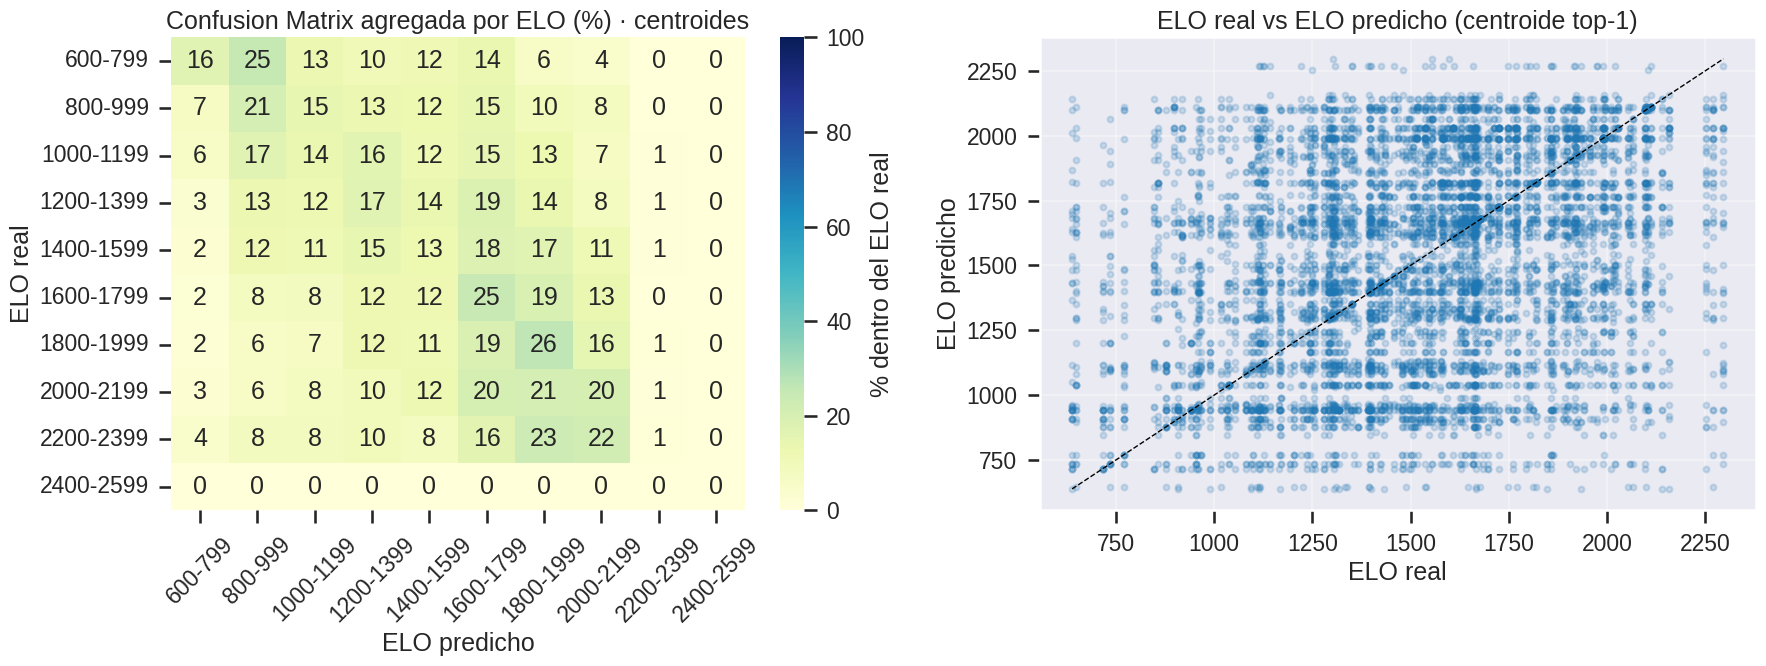

,true_elo_bin,games,players,player_accuracy,elo_mae,elo_bias,true_elo_mean,pred_elo_mean
0,600-799,200,5,8.000000,522.085022,519.265015,701.000000,1220.265015
1,800-999,480,12,5.208333,455.933319,420.845825,922.833313,1343.679199
2,1000-1199,800,20,3.125000,391.114990,283.307495,1110.449951,1393.757446
3,1200-1399,1480,37,2.500000,342.386475,141.909454,1308.783813,1450.693237
4,1400-1599,1480,37,2.702703,332.285126,1.777027,1506.135132,1507.912109
5,1600-1799,1680,42,3.452381,306.761902,-98.678574,1681.642822,1582.964233
6,1800-1999,1200,30,4.500000,343.940826,-266.584167,1901.400024,1634.815796
7,2000-2199,560,14,5.714286,444.303558,-434.739288,2076.000000,1641.260742
8,2200-2399,120,3,0.000000,650.166687,-650.166687,2273.666748,1623.500000
9,2400-2599,0,0,NaN,NaN,NaN,NaN,NaN


,true_player,true_elo,games,player_accuracy,elo_mae,elo_bias,pred_elo_mean,pred_player_mode
0,marcoebasta,2297.0,40,0.0,746.325012,-746.325012,1550.675049,asrhiuesa
1,malihe890,856.0,40,0.0,697.799988,691.250000,1547.250000,kira1982
2,serkanakman65,2253.0,40,0.0,614.150024,-614.150024,1638.849976,Arielagronomo
3,GErmaNnadIY_333,847.0,40,0.0,608.200012,588.549988,1435.550049,youcef7112
4,EdwardMartens,2271.0,40,0.0,590.025024,-590.025024,1680.974976,NourYehia
5,tony_57,2058.0,40,0.0,536.775024,-534.025024,1523.974976,kings-divine
6,I2nChess21,960.0,40,0.0,506.875000,505.625000,1465.625000,juanpavilla
7,mariano_giusti,1112.0,40,0.0,490.674988,421.325012,1533.324951,crazyfellow
8,jesaispasdutout,966.0,40,0.0,486.000000,449.399994,1415.400024,marwanabd
9,ScrewRide,2020.0,40,0.0,481.674988,-448.924988,1571.074951,Nunhez


/tmp/ipykernel_273218/3628529560.py:142: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=topk_df, x="metric", y="accuracy", palette="viridis")


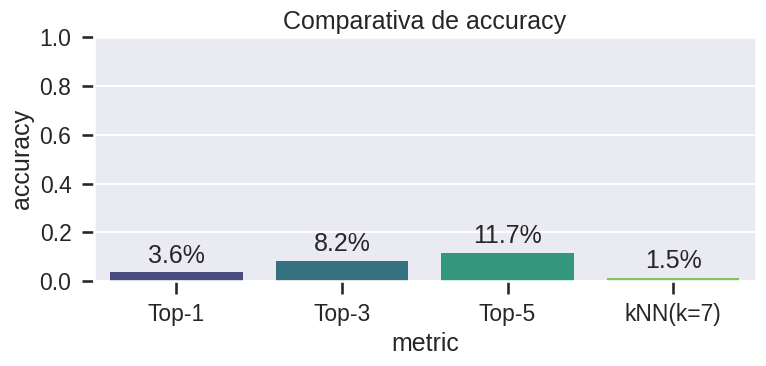

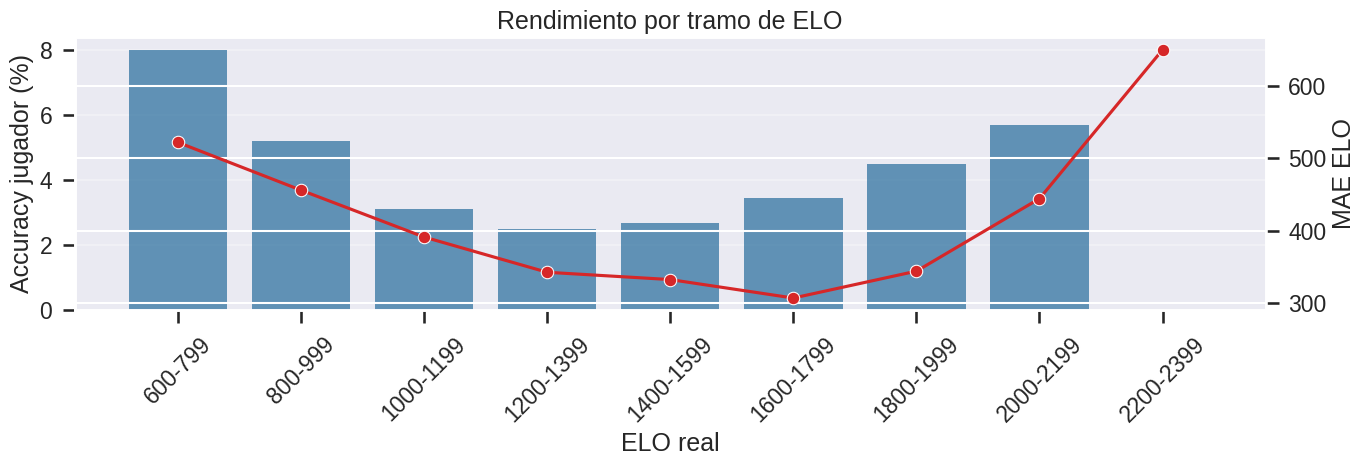

/tmp/ipykernel_273218/3628529560.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=worst_players_df, x="label", y="player_accuracy", palette="rocket")


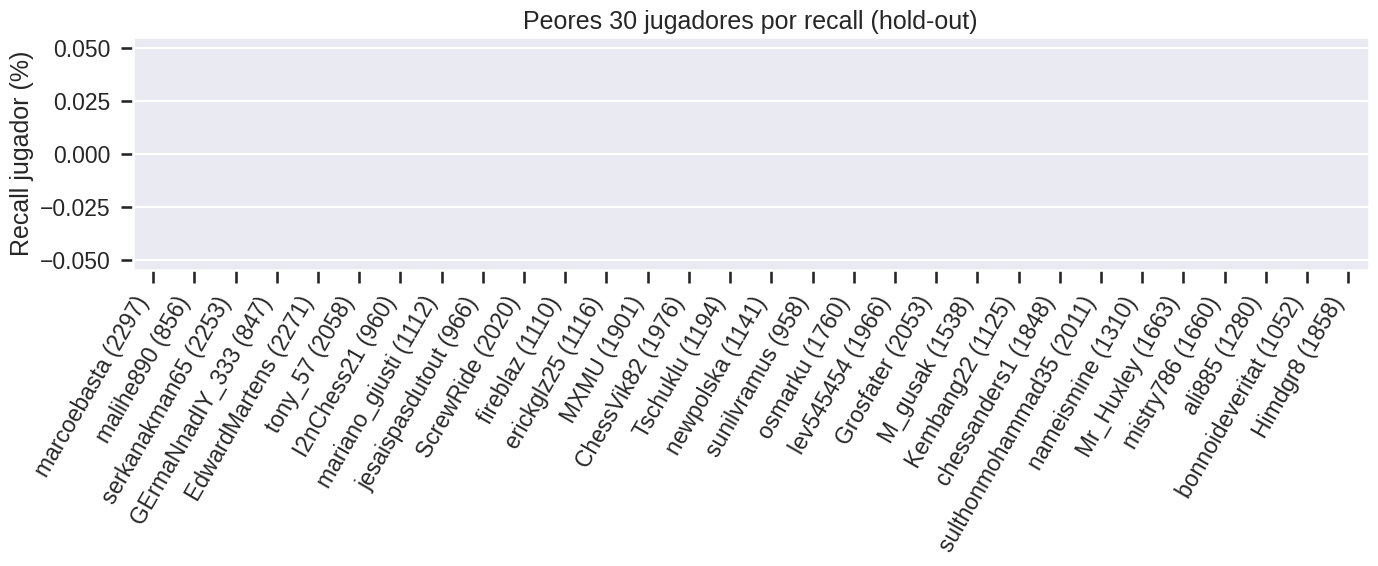

In [23]:
ELO_BIN_SIZE = 200
PLOT_FULL_PLAYER_CONFUSION = False
MAX_PLAYERS_IN_DETAIL_PLOT = 30

label_to_elo = np.array(
    [PLAYER_ELO.get(player, np.nan) for player in centroid_players],
    dtype=np.float32,
)
true_idx = np.asarray(hold_labels, dtype=np.int32)
pred_idx = np.asarray(centroid_pred, dtype=np.int32)

known_confusion_df = pd.DataFrame(
    {
        "true_label": true_idx,
        "pred_label": pred_idx,
        "true_player": [centroid_players[int(idx)] for idx in true_idx],
        "pred_player": [centroid_players[int(idx)] for idx in pred_idx],
        "true_elo": label_to_elo[true_idx],
        "pred_elo": label_to_elo[pred_idx],
    }
)
known_confusion_df["correct_player"] = known_confusion_df["true_label"] == known_confusion_df["pred_label"]
known_confusion_df["elo_error"] = known_confusion_df["pred_elo"] - known_confusion_df["true_elo"]
known_confusion_df["elo_abs_error"] = known_confusion_df["elo_error"].abs()

valid_elo_df = known_confusion_df.dropna(subset=["true_elo", "pred_elo"]).copy()
if valid_elo_df.empty:
    raise RuntimeError("No hay ELOs validos para construir la matriz agregada.")

elo_min_edge = int(np.floor(valid_elo_df[["true_elo", "pred_elo"]].min().min() / ELO_BIN_SIZE) * ELO_BIN_SIZE)
elo_max_edge = int(np.ceil(valid_elo_df[["true_elo", "pred_elo"]].max().max() / ELO_BIN_SIZE) * ELO_BIN_SIZE + ELO_BIN_SIZE)
elo_edges = np.arange(elo_min_edge, elo_max_edge + ELO_BIN_SIZE, ELO_BIN_SIZE)
elo_bin_labels = [f"{int(elo_edges[i])}-{int(elo_edges[i + 1] - 1)}" for i in range(len(elo_edges) - 1)]

valid_elo_df["true_elo_bin"] = pd.cut(
    valid_elo_df["true_elo"],
    bins=elo_edges,
    labels=elo_bin_labels,
    include_lowest=True,
    right=False,
)
valid_elo_df["pred_elo_bin"] = pd.cut(
    valid_elo_df["pred_elo"],
    bins=elo_edges,
    labels=elo_bin_labels,
    include_lowest=True,
    right=False,
)

elo_bin_cm_counts = pd.crosstab(
    valid_elo_df["true_elo_bin"],
    valid_elo_df["pred_elo_bin"],
).reindex(index=elo_bin_labels, columns=elo_bin_labels, fill_value=0)
elo_bin_cm_pct = pd.crosstab(
    valid_elo_df["true_elo_bin"],
    valid_elo_df["pred_elo_bin"],
    normalize="index",
).reindex(index=elo_bin_labels, columns=elo_bin_labels, fill_value=0) * 100

elo_bin_summary_df = (
    valid_elo_df.groupby("true_elo_bin", observed=False)
    .agg(
        games=("true_player", "count"),
        players=("true_player", "nunique"),
        player_accuracy=("correct_player", "mean"),
        elo_mae=("elo_abs_error", "mean"),
        elo_bias=("elo_error", "mean"),
        true_elo_mean=("true_elo", "mean"),
        pred_elo_mean=("pred_elo", "mean"),
    )
    .reset_index()
)
elo_bin_summary_df["player_accuracy"] = 100 * elo_bin_summary_df["player_accuracy"]

player_error_summary_df = (
    valid_elo_df.groupby(["true_player", "true_elo"], as_index=False)
    .agg(
        games=("pred_player", "count"),
        player_accuracy=("correct_player", "mean"),
        elo_mae=("elo_abs_error", "mean"),
        elo_bias=("elo_error", "mean"),
        pred_elo_mean=("pred_elo", "mean"),
        pred_player_mode=("pred_player", lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan),
    )
    .sort_values(["player_accuracy", "elo_mae", "true_elo"], ascending=[True, False, True])
    .reset_index(drop=True)
)
player_error_summary_df["player_accuracy"] = 100 * player_error_summary_df["player_accuracy"]

EVAL_TABLES_DIR = EVENT_DIR / "evaluation_tables"
EVAL_TABLES_DIR.mkdir(parents=True, exist_ok=True)
known_confusion_df.to_csv(EVAL_TABLES_DIR / "known_centroid_confusion_by_game.csv", index=False)
elo_bin_cm_counts.to_csv(EVAL_TABLES_DIR / "known_centroid_elo_bin_confusion_counts.csv")
elo_bin_cm_pct.to_csv(EVAL_TABLES_DIR / "known_centroid_elo_bin_confusion_pct.csv")
elo_bin_summary_df.to_csv(EVAL_TABLES_DIR / "known_centroid_elo_bin_summary.csv", index=False)
player_error_summary_df.to_csv(EVAL_TABLES_DIR / "known_centroid_player_error_summary.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(
    elo_bin_cm_pct,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    vmin=0,
    vmax=100,
    cbar_kws={"label": "% dentro del ELO real"},
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix agregada por ELO (%) · centroides")
axes[0].set_xlabel("ELO predicho")
axes[0].set_ylabel("ELO real")
axes[0].tick_params(axis="x", rotation=45)
axes[0].tick_params(axis="y", rotation=0)

axes[1].scatter(
    valid_elo_df["true_elo"],
    valid_elo_df["pred_elo"],
    alpha=0.18,
    s=18,
    color="tab:blue",
)
lo = float(min(valid_elo_df["true_elo"].min(), valid_elo_df["pred_elo"].min()))
hi = float(max(valid_elo_df["true_elo"].max(), valid_elo_df["pred_elo"].max()))
axes[1].plot([lo, hi], [lo, hi], "k--", linewidth=1)
axes[1].set_title("ELO real vs ELO predicho (centroide top-1)")
axes[1].set_xlabel("ELO real")
axes[1].set_ylabel("ELO predicho")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(elo_bin_summary_df)
display(player_error_summary_df.head(MAX_PLAYERS_IN_DETAIL_PLOT))

topk_df = pd.DataFrame(
    {
        "metric": ["Top-1", "Top-3", "Top-5", f"kNN(k={knn_k})"],
        "accuracy": [acc_top1, acc_top3, acc_top5, knn_acc],
    }
)
plt.figure(figsize=(8, 4))
ax = sns.barplot(data=topk_df, x="metric", y="accuracy", palette="viridis")
ax.set_ylim(0, 1)
ax.set_title("Comparativa de accuracy")
for i, v in enumerate(topk_df["accuracy"]):
    ax.text(i, v + 0.02, f"{v:.1%}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

fig, ax1 = plt.subplots(figsize=(14, 5))
plot_summary_df = elo_bin_summary_df.dropna(subset=["games"]).copy()
sns.barplot(
    data=plot_summary_df,
    x="true_elo_bin",
    y="player_accuracy",
    color="tab:blue",
    alpha=0.75,
    ax=ax1,
)
ax1.set_ylabel("Accuracy jugador (%)")
ax1.set_xlabel("ELO real")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(True, axis="y", alpha=0.3)

ax2 = ax1.twinx()
sns.lineplot(
    data=plot_summary_df,
    x="true_elo_bin",
    y="elo_mae",
    marker="o",
    color="tab:red",
    ax=ax2,
)
ax2.set_ylabel("MAE ELO")
ax1.set_title("Rendimiento por tramo de ELO")
plt.tight_layout()
plt.show()

worst_players_df = player_error_summary_df.head(MAX_PLAYERS_IN_DETAIL_PLOT).copy()
worst_players_df["label"] = worst_players_df.apply(
    lambda r: f"{r['true_player']} ({int(round(r['true_elo']))})",
    axis=1,
)
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=worst_players_df, x="label", y="player_accuracy", palette="rocket")
ax.set_title(f"Peores {MAX_PLAYERS_IN_DETAIL_PLOT} jugadores por recall (hold-out)")
ax.set_ylabel("Recall jugador (%)")
ax.set_xlabel("")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

if PLOT_FULL_PLAYER_CONFUSION:
    ordered_players = sorted(
        centroid_players,
        key=lambda p: (
            np.isnan(PLAYER_ELO.get(p, np.nan)),
            PLAYER_ELO.get(p, np.inf),
            p.lower(),
        ),
    )
    order_idx = [centroid_players.index(p) for p in ordered_players]
    cm_counts = cm_known[np.ix_(order_idx, order_idx)]
    cm_sum = cm_counts.sum(axis=1, keepdims=True)
    cm_pct = np.divide(cm_counts, np.maximum(cm_sum, 1), where=cm_sum > 0) * 100.0
    labels_elo = []
    for p in ordered_players:
        elo = PLAYER_ELO.get(p, np.nan)
        labels_elo.append(f"{p} ({int(round(elo)) if not np.isnan(elo) else '?'})")

    fig, axes = plt.subplots(1, 2, figsize=(28, 12))
    sns.heatmap(
        cm_counts,
        annot=False,
        cmap="Blues",
        xticklabels=labels_elo,
        yticklabels=labels_elo,
        ax=axes[0],
    )
    axes[0].set_title("Confusion Matrix completa (counts) · inspeccion manual")
    axes[0].set_xlabel("Prediccion")
    axes[0].set_ylabel("Jugador real")

    sns.heatmap(
        cm_pct,
        annot=False,
        cmap="YlGnBu",
        xticklabels=labels_elo,
        yticklabels=labels_elo,
        ax=axes[1],
    )
    axes[1].set_title("Confusion Matrix completa (fila %) · inspeccion manual")
    axes[1].set_xlabel("Prediccion")
    axes[1].set_ylabel("Jugador real")

    for ax in axes:
        ax.tick_params(axis="x", rotation=90, labelsize=5)
        ax.tick_params(axis="y", rotation=0, labelsize=5)
    plt.tight_layout()
    plt.show()


ANÁLISIS DE DISTANCIAS · HOLD-OUT
Distancia media a centroide propio:            0.038252
Distancia media a centroide ajeno más cercano: 0.035336
Ratio own/other:                               1.0825
Margen efectivo (other-own):                   -0.002917


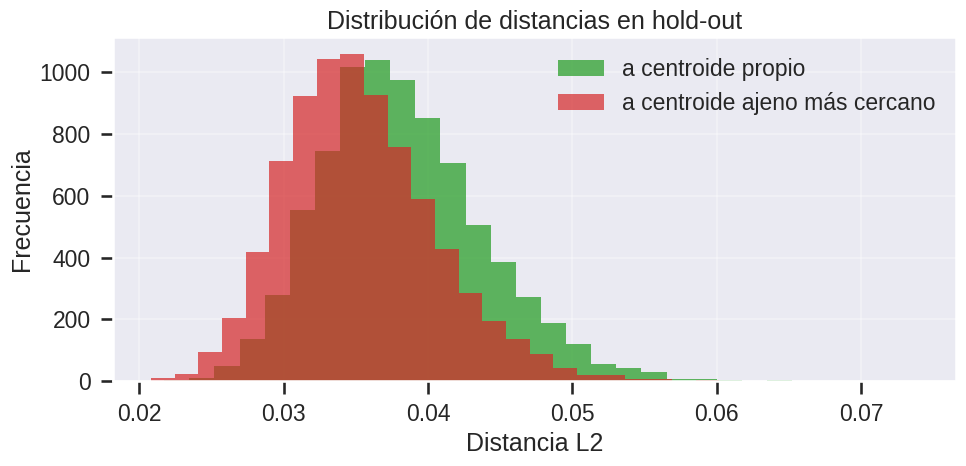

In [20]:
own_dist = centroid_dists[np.arange(len(hold_labels)), hold_labels]
mask_other = np.ones_like(centroid_dists, dtype=bool)
mask_other[np.arange(len(hold_labels)), hold_labels] = False
nearest_other = np.min(np.where(mask_other, centroid_dists, np.inf), axis=1)

ratio = float(np.mean(own_dist) / np.mean(nearest_other))
margin = float(np.mean(nearest_other) - np.mean(own_dist))

print("ANÁLISIS DE DISTANCIAS · HOLD-OUT")
print("=" * 80)
print(f"Distancia media a centroide propio:            {np.mean(own_dist):.6f}")
print(f"Distancia media a centroide ajeno más cercano: {np.mean(nearest_other):.6f}")
print(f"Ratio own/other:                               {ratio:.4f}")
print(f"Margen efectivo (other-own):                   {margin:.6f}")
print("=" * 80)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(own_dist, bins=30, alpha=0.75, label="a centroide propio", color="tab:green")
ax.hist(
    nearest_other,
    bins=30,
    alpha=0.70,
    label="a centroide ajeno más cercano",
    color="tab:red",
)
ax.set_title("Distribución de distancias en hold-out")
ax.set_xlabel("Distancia L2")
ax.set_ylabel("Frecuencia")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5) Open-set: jugadores no vistos + similitud por ELO


In [19]:
def iter_zst_files(players_root: Path):
    for prefix_dir in sorted(players_root.iterdir()):
        if not prefix_dir.is_dir():
            continue
        for zst_path in prefix_dir.glob("*.pgn.zst"):
            yield zst_path


def select_unknown_players(
    known_players: List[str],
    max_players: int,
    candidate_pool: int,
    min_elo: int,
    max_elo: int,
    seed: int,
) -> pd.DataFrame:
    known_norm = {_norm_player(p) for p in known_players}
    candidates = []

    for zst_path in iter_zst_files(ZST_PLAYERS_DIR):
        player = zst_path.name[:-8]  # remove .pgn.zst
        if _norm_player(player) in known_norm:
            continue

        elo = extract_elo_from_zst(zst_path)
        if elo is None:
            continue
        if not (min_elo <= elo <= max_elo):
            continue

        candidates.append(
            {
                "player": player,
                "elo": int(elo),
                "zst_path": str(zst_path),
            }
        )

    if not candidates:
        raise RuntimeError("No se encontraron jugadores no vistos con ELO válido.")

    cand_df = pd.DataFrame(candidates)
    if len(cand_df) > candidate_pool:
        cand_df = cand_df.sample(candidate_pool, random_state=seed).reset_index(drop=True)

    bins = list(range(600, 3001, 200))
    cand_df["elo_bin"] = pd.cut(
        cand_df["elo"],
        bins=bins,
        labels=False,
        include_lowest=True,
    )

    selected_rows = []
    for elo_bin in sorted(cand_df["elo_bin"].dropna().unique()):
        if len(selected_rows) >= max_players:
            break
        group = cand_df[cand_df["elo_bin"] == elo_bin]
        selected_rows.append(group.sample(1, random_state=seed).iloc[0])

    if len(selected_rows) < max_players:
        used = {r["player"] for r in selected_rows}
        remainder = cand_df[~cand_df["player"].isin(used)]
        if not remainder.empty:
            extra = remainder.sample(
                min(max_players - len(selected_rows), len(remainder)),
                random_state=seed,
            )
            for _, row in extra.iterrows():
                selected_rows.append(row)

    return (
        pd.DataFrame(selected_rows)
        .drop(columns=["elo_bin"], errors="ignore")
        .sort_values("elo")
        .reset_index(drop=True)
    )


def infer_unknown_players(
    unknown_players_df: pd.DataFrame,
    games_per_player: int,
) -> pd.DataFrame:
    rows = []
    for _, row in unknown_players_df.iterrows():
        unknown_player = row["player"]
        unknown_elo = float(row["elo"])
        zst_path = Path(row["zst_path"])

        print(f"Procesando no-visto: {unknown_player} (ELO~{int(unknown_elo)})")
        games = read_player_games_from_zst(
            zst_path=zst_path,
            player_name=unknown_player,
            max_games=games_per_player,
        )
        print(f"  partidas útiles: {len(games)}")

        for game_idx, game, side in games:
            try:
                boards, heats = build_single_game_tensor(
                    game=game,
                    side=side,
                    sequence_len=CONFIG.sequence_len,
                    fullmove_start=CONFIG.fullmove_start,
                    fullmove_end=CONFIG.fullmove_end,
                    image_size=CONFIG.image_size,
                )
            except Exception:
                continue

            emb = embedding_model.predict(
                {"board_sequence": boards, "heat_sequence": heats},
                verbose=0,
            )[0]
            dists = np.linalg.norm(centroid_matrix - emb[None, :], axis=1)
            order = np.argsort(dists)

            top1_idx = int(order[0])
            top2_idx = int(order[1]) if len(order) > 1 else int(order[0])
            top1_player = centroid_players[top1_idx]
            top1_dist = float(dists[top1_idx])
            top2_dist = float(dists[top2_idx])
            margin = float(top2_dist - top1_dist)

            rows.append(
                {
                    "unknown_player": unknown_player,
                    "unknown_elo": unknown_elo,
                    "game_index": int(game_idx),
                    "side": side,
                    "pred_player_top1": top1_player,
                    "pred_elo_top1": PLAYER_ELO.get(top1_player, np.nan),
                    "top1_distance": top1_dist,
                    "top2_distance": top2_dist,
                    "top12_margin": margin,
                }
            )

    if not rows:
        raise RuntimeError("No se pudieron generar predicciones para jugadores no vistos.")
    return pd.DataFrame(rows)


unknown_players_df = select_unknown_players(
    known_players=SELECTED_PLAYERS,
    max_players=CONFIG.unknown_players_to_test,
    candidate_pool=CONFIG.unknown_candidate_pool,
    min_elo=CONFIG.unknown_min_elo,
    max_elo=CONFIG.unknown_max_elo,
    seed=SEED,
)
display(unknown_players_df)

unknown_predictions_df = infer_unknown_players(
    unknown_players_df=unknown_players_df,
    games_per_player=CONFIG.unknown_games_per_player,
)
unknown_predictions_df["elo_abs_error"] = (
    unknown_predictions_df["pred_elo_top1"] - unknown_predictions_df["unknown_elo"]
).abs()
display(unknown_predictions_df.head(30))
print(f"Predicciones no-vistos: {len(unknown_predictions_df)}")


,player,elo,zst_path
0,charm254,892,/pgn_data/players/ch/charm254.pgn.zst
1,MEHDI_MALAKOOTIFAR,1033,/pgn_data/players/me/MEHDI_MALAKOOTIFAR.pgn.zst
2,ogoodwin505,1073,/pgn_data/players/og/ogoodwin505.pgn.zst
3,Maheswarareddy4321,1115,/pgn_data/players/ma/Maheswarareddy4321.pgn.zst
4,radagonlord,1157,/pgn_data/players/ra/radagonlord.pgn.zst
5,theWickedChron,1195,/pgn_data/players/th/theWickedChron.pgn.zst
6,patel87,1236,/pgn_data/players/pa/patel87.pgn.zst
7,Tituskapapilo1,1239,/pgn_data/players/ti/Tituskapapilo1.pgn.zst
8,Maximus551,1272,/pgn_data/players/ma/Maximus551.pgn.zst
9,MasterBratan,1354,/pgn_data/players/ma/MasterBratan.pgn.zst


Procesando no-visto: charm254 (ELO~892)
  partidas útiles: 20
Procesando no-visto: MEHDI_MALAKOOTIFAR (ELO~1033)
  partidas útiles: 20
Procesando no-visto: ogoodwin505 (ELO~1073)
  partidas útiles: 20
Procesando no-visto: Maheswarareddy4321 (ELO~1115)
  partidas útiles: 20
Procesando no-visto: radagonlord (ELO~1157)
  partidas útiles: 20
Procesando no-visto: theWickedChron (ELO~1195)
  partidas útiles: 20
Procesando no-visto: patel87 (ELO~1236)
  partidas útiles: 20
Procesando no-visto: Tituskapapilo1 (ELO~1239)
  partidas útiles: 20
Procesando no-visto: Maximus551 (ELO~1272)
  partidas útiles: 20
Procesando no-visto: MasterBratan (ELO~1354)
  partidas útiles: 20
Procesando no-visto: opeyemiafo (ELO~1410)
  partidas útiles: 20
Procesando no-visto: wiebe12144 (ELO~1443)
  partidas útiles: 20
Procesando no-visto: Lu14082007 (ELO~1550)
  partidas útiles: 20
Procesando no-visto: EnterSteelman (ELO~1567)
  partidas útiles: 20
Procesando no-visto: Lobinha_BR (ELO~1609)
  partidas útiles: 20


,unknown_player,unknown_elo,game_index,side,pred_player_top1,pred_elo_top1,top1_distance,top2_distance,top12_margin,elo_abs_error
0,charm254,892.0,1,white,mathieuCham,941.0,0.031441,0.031512,0.000071,49.0
1,charm254,892.0,2,white,PhilOne,1628.0,0.036139,0.036228,0.000089,736.0
2,charm254,892.0,3,black,MarkusMake,908.0,0.038637,0.039383,0.000746,16.0
3,charm254,892.0,4,black,durple,1038.0,0.039033,0.039068,0.000036,146.0
4,charm254,892.0,5,black,AdamIsGonnaLose709,1289.0,0.042002,0.042407,0.000405,397.0
5,charm254,892.0,6,black,chessanders1,1848.0,0.031685,0.031961,0.000276,956.0
6,charm254,892.0,7,black,GErmaNnadIY_333,847.0,0.039269,0.039854,0.000586,45.0
7,charm254,892.0,8,white,abrakadabra123,1771.0,0.044933,0.045432,0.000499,879.0
8,charm254,892.0,9,white,Miguel1969,1435.0,0.036802,0.037007,0.000205,543.0
9,charm254,892.0,10,black,salgir52,1768.0,0.040548,0.041104,0.000556,876.0


Predicciones no-vistos: 400


OPEN-SET / JUGADORES NO VISTOS
Jugadores no vistos evaluados: 20
Partidas no vistas evaluadas: 400
MAE ELO (pred_top1 vs elo real): 203.7
Correlación ELO real vs ELO predicho: 0.737
Umbral OOD (q=95% conocidos): 0.0448
False reject conocidos: 5.00%
Reject no-vistos: 3.75%


,unknown_player,unknown_elo,games_evaluated,pred_player_mode,pred_elo_mean,top1_dist_mean,top12_margin_mean,elo_abs_error
0,charm254,892.0,20,AdamIsGonnaLose709,1486.25,0.036425,0.000367,594.25
1,MEHDI_MALAKOOTIFAR,1033.0,20,NourYehia,1597.45,0.035602,0.000357,564.45
2,ogoodwin505,1073.0,20,mathieuCham,1204.20,0.036600,0.000596,131.20
3,Maheswarareddy4321,1115.0,20,lithi140817,1482.85,0.035179,0.000535,367.85
4,radagonlord,1157.0,20,Karl_Plus,1509.55,0.034149,0.000355,352.55
5,theWickedChron,1195.0,20,asrhiuesa,1399.95,0.034981,0.000423,204.95
6,patel87,1236.0,20,Warriors73andnine,1443.00,0.035831,0.000523,207.00
7,Tituskapapilo1,1239.0,20,eagle_sajan,1303.15,0.034864,0.000537,64.15
8,Maximus551,1272.0,20,Mauricio060215,1355.10,0.034789,0.000469,83.10
9,MasterBratan,1354.0,20,Miguel1969,1367.65,0.034130,0.000405,13.65


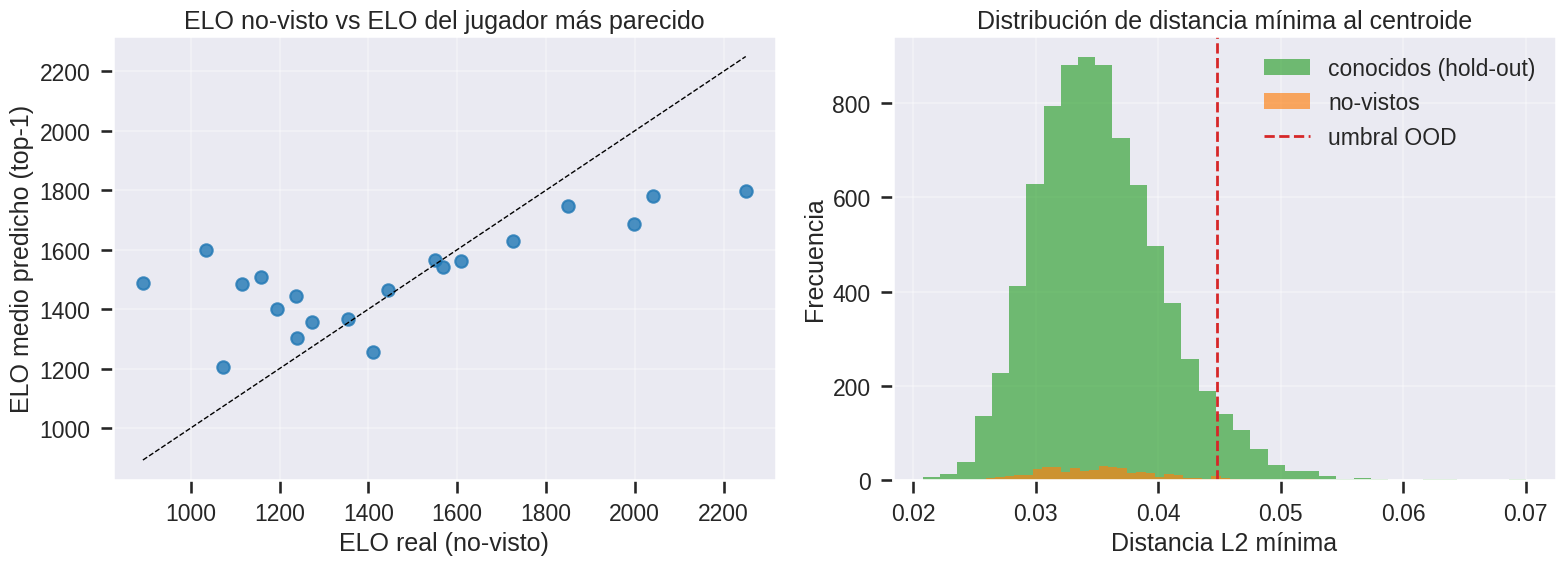

/tmp/ipykernel_273218/1667144621.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=err_df, x="unknown_player", y="elo_abs_error", palette="magma")


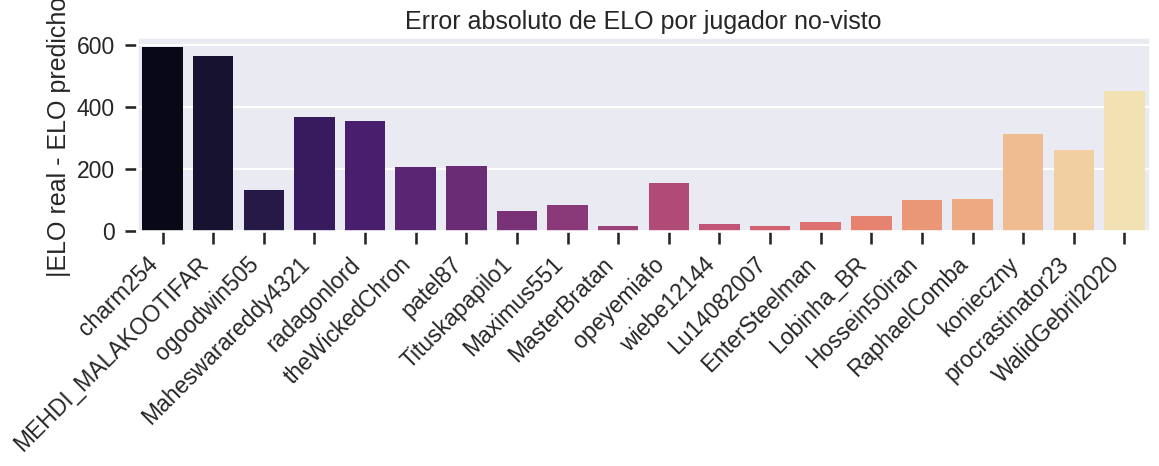

In [18]:
def _mode_first(series: pd.Series):
    m = series.mode(dropna=True)
    return m.iloc[0] if not m.empty else np.nan


unknown_summary_df = (
    unknown_predictions_df.groupby(["unknown_player", "unknown_elo"], as_index=False)
    .agg(
        games_evaluated=("game_index", "count"),
        pred_player_mode=("pred_player_top1", _mode_first),
        pred_elo_mean=("pred_elo_top1", "mean"),
        top1_dist_mean=("top1_distance", "mean"),
        top12_margin_mean=("top12_margin", "mean"),
    )
    .sort_values("unknown_elo")
    .reset_index(drop=True)
)
unknown_summary_df["elo_abs_error"] = (
    unknown_summary_df["pred_elo_mean"] - unknown_summary_df["unknown_elo"]
).abs()

known_min_dist = np.min(centroid_dists, axis=1)
unknown_min_dist = unknown_predictions_df["top1_distance"].values
ood_threshold = float(np.quantile(known_min_dist, CONFIG.ood_quantile))

known_false_reject_rate = float(np.mean(known_min_dist > ood_threshold))
unknown_reject_rate = float(np.mean(unknown_min_dist > ood_threshold))

elo_eval_df = unknown_summary_df.dropna(subset=["pred_elo_mean", "unknown_elo"]).copy()
elo_mae = float(np.mean(np.abs(elo_eval_df["pred_elo_mean"] - elo_eval_df["unknown_elo"])))
elo_corr = (
    float(np.corrcoef(elo_eval_df["unknown_elo"], elo_eval_df["pred_elo_mean"])[0, 1])
    if len(elo_eval_df) >= 2
    else np.nan
)

print("=" * 80)
print("OPEN-SET / JUGADORES NO VISTOS")
print("=" * 80)
print(f"Jugadores no vistos evaluados: {unknown_summary_df.shape[0]}")
print(f"Partidas no vistas evaluadas: {unknown_predictions_df.shape[0]}")
print(f"MAE ELO (pred_top1 vs elo real): {elo_mae:.1f}")
print(f"Correlación ELO real vs ELO predicho: {elo_corr:.3f}")
print(f"Umbral OOD (q={CONFIG.ood_quantile:.0%} conocidos): {ood_threshold:.4f}")
print(f"False reject conocidos: {known_false_reject_rate:.2%}")
print(f"Reject no-vistos: {unknown_reject_rate:.2%}")
print("=" * 80)
display(unknown_summary_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(
    elo_eval_df["unknown_elo"],
    elo_eval_df["pred_elo_mean"],
    alpha=0.8,
    s=80,
    color="tab:blue",
)
if not elo_eval_df.empty:
    lo = float(min(elo_eval_df["unknown_elo"].min(), elo_eval_df["pred_elo_mean"].min()))
    hi = float(max(elo_eval_df["unknown_elo"].max(), elo_eval_df["pred_elo_mean"].max()))
    axes[0].plot([lo, hi], [lo, hi], "k--", linewidth=1)
axes[0].set_title("ELO no-visto vs ELO del jugador más parecido")
axes[0].set_xlabel("ELO real (no-visto)")
axes[0].set_ylabel("ELO medio predicho (top-1)")
axes[0].grid(True, alpha=0.3)

axes[1].hist(known_min_dist, bins=35, alpha=0.65, label="conocidos (hold-out)", color="tab:green")
axes[1].hist(unknown_min_dist, bins=35, alpha=0.65, label="no-vistos", color="tab:orange")
axes[1].axvline(ood_threshold, color="tab:red", linestyle="--", linewidth=2, label="umbral OOD")
axes[1].set_title("Distribución de distancia mínima al centroide")
axes[1].set_xlabel("Distancia L2 mínima")
axes[1].set_ylabel("Frecuencia")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
err_df = unknown_summary_df.sort_values("unknown_elo")
ax = sns.barplot(data=err_df, x="unknown_player", y="elo_abs_error", palette="magma")
ax.set_title("Error absoluto de ELO por jugador no-visto")
ax.set_xlabel("")
ax.set_ylabel("|ELO real - ELO predicho|")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


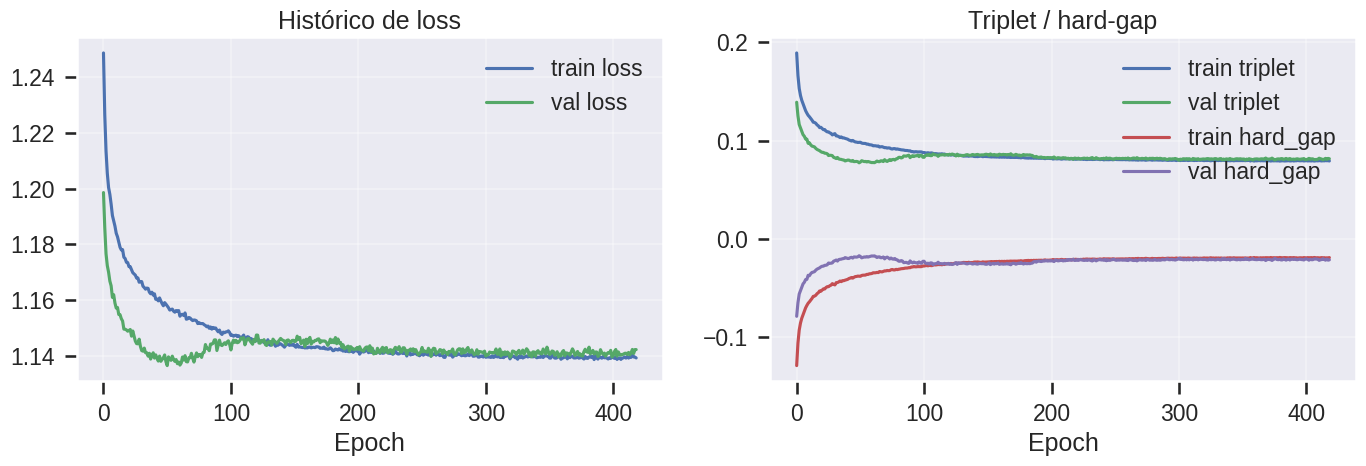

RESUMEN EJECUTIVO
Top-1 hold-out: 3.59%
Top-3 hold-out: 8.25%
Top-5 hold-out: 11.72%
kNN hold-out:   1.50%
False reject conocidos (OOD): 5.00%
Reject no-vistos (OOD):       3.75%
MAE ELO no-vistos: 203.7 puntos
Correlación ELO real/predicho: 0.737


In [17]:
history_df = pd.read_csv(HISTORY_CSV_PATH) if HISTORY_CSV_PATH.exists() else pd.DataFrame()
if not history_df.empty:
    if "epoch" not in history_df.columns:
        history_df = history_df.reset_index().rename(columns={"index": "epoch"})

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history_df["epoch"], history_df.get("loss", np.nan), label="train loss")
    if "val_loss" in history_df.columns:
        axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val loss")
    axes[0].set_title("Histórico de loss")
    axes[0].set_xlabel("Epoch")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    if "triplet_loss" in history_df.columns:
        axes[1].plot(history_df["epoch"], history_df["triplet_loss"], label="train triplet")
    if "val_triplet_loss" in history_df.columns:
        axes[1].plot(history_df["epoch"], history_df["val_triplet_loss"], label="val triplet")
    if "hard_gap" in history_df.columns:
        axes[1].plot(history_df["epoch"], history_df["hard_gap"], label="train hard_gap")
    if "val_hard_gap" in history_df.columns:
        axes[1].plot(history_df["epoch"], history_df["val_hard_gap"], label="val hard_gap")
    axes[1].set_title("Triplet / hard-gap")
    axes[1].set_xlabel("Epoch")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def pct(x: float) -> str:
    return f"{x:.2%}"


print("RESUMEN EJECUTIVO")
print("=" * 80)
print(f"Top-1 hold-out: {pct(acc_top1)}")
print(f"Top-3 hold-out: {pct(acc_top3)}")
print(f"Top-5 hold-out: {pct(acc_top5)}")
print(f"kNN hold-out:   {pct(knn_acc)}")
print(f"False reject conocidos (OOD): {pct(known_false_reject_rate)}")
print(f"Reject no-vistos (OOD):       {pct(unknown_reject_rate)}")
print(f"MAE ELO no-vistos: {elo_mae:.1f} puntos")
if not np.isnan(elo_corr):
    print(f"Correlación ELO real/predicho: {elo_corr:.3f}")
else:
    print("Correlación ELO: no disponible")
print("=" * 80)


In [16]:
def predict_player_from_pgn(
    pgn_path: Path,
    game_index: int = 1,
    side: str = "white",
    top_k: int = 5,
) -> pd.DataFrame:
    if not pgn_path.exists():
        raise FileNotFoundError(f"No existe {pgn_path}")
    if pgn_path.is_dir():
        raise ValueError("pgn_path debe ser un archivo .pgn, no un directorio.")

    with open(pgn_path, "r", encoding="utf-8", errors="replace") as f:
        game = None
        for _ in range(game_index):
            game = chess.pgn.read_game(f)
            if game is None:
                raise RuntimeError(f"No existe game_index={game_index} en {pgn_path}")

    boards, heats = build_single_game_tensor(
        game=game,
        side=side,
        sequence_len=CONFIG.sequence_len,
        fullmove_start=CONFIG.fullmove_start,
        fullmove_end=CONFIG.fullmove_end,
        image_size=CONFIG.image_size,
    )
    emb = embedding_model.predict(
        {"board_sequence": boards, "heat_sequence": heats},
        verbose=0,
    )[0]

    dists = np.linalg.norm(centroid_matrix - emb[None, :], axis=1)
    order = np.argsort(dists)[: max(1, top_k)]

    rows = []
    for rank_idx, idx in enumerate(order, start=1):
        player = centroid_players[idx]
        rows.append(
            {
                "rank": rank_idx,
                "player": player,
                "player_elo": PLAYER_ELO.get(player, np.nan),
                "distance": float(dists[idx]),
            }
        )
    return pd.DataFrame(rows)


print("Helper listo: predict_player_from_pgn(...)")
example_player = TRAINED_PLAYERS[0] if TRAINED_PLAYERS else "<player>"
example_pgn = PGN_TESTS_DIR / f"{example_player}.pgn"
print("Ejemplo:")
print(
    f"predict_player_from_pgn(Path(r'{example_pgn}'), game_index=1, side='white', top_k=5)"
)


Helper listo: predict_player_from_pgn(...)
Ejemplo:
predict_player_from_pgn(Path(r'/workspace/code/labs/notebooks/output/events/compressed_130/pgn_tests/AdamIsGonnaLose709.pgn'), game_index=1, side='white', top_k=5)


In [15]:
predict_player_from_pgn(Path(r'/workspace/code/labs/notebooks/output/events/compressed_120/pgn_tests/Arsibbalt-1991.pgn'), game_index=1, side='white', top_k=5)

,rank,player,player_elo,distance
0,1,Cesarbal123,1919.0,0.028290
1,2,ncups,1249.0,0.028377
2,3,junshah,1396.0,0.028421
3,4,reginalouise,1257.0,0.028488
4,5,Starman6059,1302.0,0.028510
